1. Load dataset & Keep final test set

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from preprocess import preprocess


# =========================
# 1. Load dataset
# =========================

df = pd.read_json("../donnees/articles.json")

X = df["body"]
y = df["categories"].str[0]


# =========================
# 2. Keep final test set
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


2. Development Data

In [2]:
print("=== DEVELOPMENT DATA ===")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nNumber of samples:", len(X_train))

print("\nCategory distribution:")
print(y_train.value_counts())

=== DEVELOPMENT DATA ===
X_train shape: (16800,)
y_train shape: (16800,)

Number of samples: 16800

Category distribution:
categories
ثقافة     2800
دولي      2800
اقتصاد    2800
رياضة     2800
سياسة     2800
مجتمع     2800
Name: count, dtype: int64


3. Preprocessing

4. Embedding

In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

print("Classes:")
for i, category in enumerate(label_encoder.classes_):
    print(i, "→", category)

Classes:
0 → اقتصاد
1 → ثقافة
2 → دولي
3 → رياضة
4 → سياسة
5 → مجتمع


In [4]:
from sklearn.model_selection import train_test_split

X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_train,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

print("Training samples:", len(X_ft_train))
print("Validation samples:", len(X_ft_val))

Training samples: 13440
Validation samples: 3360


In [5]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": X_ft_train.tolist(),
    "labels": y_ft_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_ft_val.tolist(),
    "labels": y_ft_val.tolist()
})

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['text', 'labels'],
    num_rows: 13440
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 3360
})


In [6]:
from transformers import AutoTokenizer

model_name = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded.")

Tokenizer loaded.


In [7]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=512
    )

In [8]:
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/13440 [00:00<?, ? examples/s]

Map:   0%|          | 0/3360 [00:00<?, ? examples/s]

In [9]:
print(train_tokenized)
print(val_tokenized)

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 13440
})
Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3360
})


In [10]:
import numpy as np

sample_lengths = [
    len(tokenizer.encode(text, truncation=False))
    for text in X_ft_train.iloc[:1000]
]

print("Average tokens:", np.mean(sample_lengths))
print("Maximum tokens:", np.max(sample_lengths))
print("Median tokens:", np.median(sample_lengths))
print("Articles > 512 tokens:", sum(
    length > 512 for length in sample_lengths
))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (650 > 512). Running this sequence through the model will result in indexing errors


Average tokens: 262.067
Maximum tokens: 1506
Median tokens: 218.0
Articles > 512 tokens: 69


In [11]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={
        i: category
        for i, category in enumerate(label_encoder.classes_)
    },
    label2id={
        category: i
        for i, category in enumerate(label_encoder.classes_)
    }
)

print("AraBERT classification model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AraBERT classification model loaded.


In [12]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

In [14]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./arabert_news_classifier",

    num_train_epochs=3,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,

    gradient_accumulation_steps=2,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none",

    fp16=True
)

In [15]:
import importlib.metadata

print("PEFT:", importlib.metadata.version("peft"))
print("Transformers:", importlib.metadata.version("transformers"))

PEFT: 0.20.0
Transformers: 5.16.1


In [16]:
from transformers import AutoModelForSequenceClassification

model_name = "aubmindlab/bert-base-arabertv02"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={
        i: category
        for i, category in enumerate(label_encoder.classes_)
    },
    label2id={
        category: i
        for i, category in enumerate(label_encoder.classes_)
    }
)

print("Model loaded successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.


In [17]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.815598,0.353793,0.907440,0.906711
2,0.469160,0.368789,0.914286,0.913672
3,0.391617,0.427434,0.914583,0.914204


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5040, training_loss=0.5937188776712569, metrics={'train_runtime': 1061.4673, 'train_samples_per_second': 37.985, 'train_steps_per_second': 4.748, 'total_flos': 7946305026052608.0, 'train_loss': 0.5937188776712569, 'epoch': 3.0})

In [19]:
y_test_encoded = label_encoder.transform(y_test)

print("Number of test labels:", len(y_test_encoded))
print("First 10 encoded labels:", y_test_encoded[:10])

Number of test labels: 4200
First 10 encoded labels: [5 5 0 4 4 2 5 4 1 4]


In [20]:
label_encoder.transform(y_test)

array([5, 5, 0, ..., 5, 2, 4])

In [21]:
from datasets import Dataset

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "labels": y_test_encoded.tolist()
})

print(test_dataset)

Dataset({
    features: ['text', 'labels'],
    num_rows: 4200
})


In [22]:
test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print(test_tokenized)

Map:   0%|          | 0/4200 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4200
})


In [24]:
test_results = trainer.predict(test_tokenized)
print(test_results)

PredictionOutput(predictions=array([[-1.6904297 , -1.3203125 , -1.7998047 , -2.9101562 , -0.8754883 ,
         7.0859375 ],
       [-1.0478516 , -2.4960938 , -1.8037109 , -3.2265625 ,  6.7382812 ,
        -0.51660156],
       [ 6.4648438 , -1.4677734 , -2.9238281 , -3.4570312 , -1.2871094 ,
        -0.26733398],
       ...,
       [-0.36328125, -1.9599609 , -2.6386719 , -3.2382812 , -0.64941406,
         7.0039062 ],
       [-1.6142578 , -1.9384766 ,  7.6640625 , -2.5488281 , -1.3242188 ,
        -0.62597656],
       [-0.5126953 , -2.9433594 , -2.6972656 , -3.3417969 ,  5.7109375 ,
         1.2783203 ]], dtype=float32), label_ids=array([5, 5, 0, ..., 5, 2, 4]), metrics={'test_loss': 0.4192839562892914, 'test_accuracy': 0.9138095238095238, 'test_macro_f1': 0.9133489096645744, 'test_runtime': 28.1571, 'test_samples_per_second': 149.163, 'test_steps_per_second': 18.645})


In [28]:
import numpy as np

test_predictions = np.argmax(
    test_results.predictions,
    axis=-1
)

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:", test_predictions[:10])

Number of predictions: 4200
First 10 predictions: [5 4 0 4 4 2 5 4 1 2]


In [29]:
from sklearn.metrics import accuracy_score, f1_score

test_accuracy = accuracy_score(
    y_test_encoded,
    test_predictions
)

test_macro_f1 = f1_score(
    y_test_encoded,
    test_predictions,
    average="macro"
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Macro F1 : {test_macro_f1:.4f}")

Test Accuracy : 0.9138
Test Macro F1 : 0.9133


In [31]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test_encoded,
    test_predictions,
    target_names=label_encoder.classes_,
    digits=4
)

print(report)

              precision    recall  f1-score   support

      اقتصاد     0.8746    0.8871    0.8809       700
       ثقافة     0.9371    0.9571    0.9470       700
        دولي     0.9163    0.9543    0.9349       700
       رياضة     0.9986    0.9971    0.9979       700
       سياسة     0.8779    0.8629    0.8703       700
       مجتمع     0.8756    0.8243    0.8492       700

    accuracy                         0.9138      4200
   macro avg     0.9133    0.9138    0.9133      4200
weighted avg     0.9133    0.9138    0.9133      4200



In [32]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(
    y_test_encoded,
    test_predictions
)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

print(cm_df)

        اقتصاد  ثقافة  دولي  رياضة  سياسة  مجتمع
اقتصاد     621     15     8      0     32     24
ثقافة        8    670     5      0      9      8
دولي         1      8   668      0      8     15
رياضة        0      0     1    698      0      1
سياسة       34      8    20      0    604     34
مجتمع       46     14    27      1     35    577


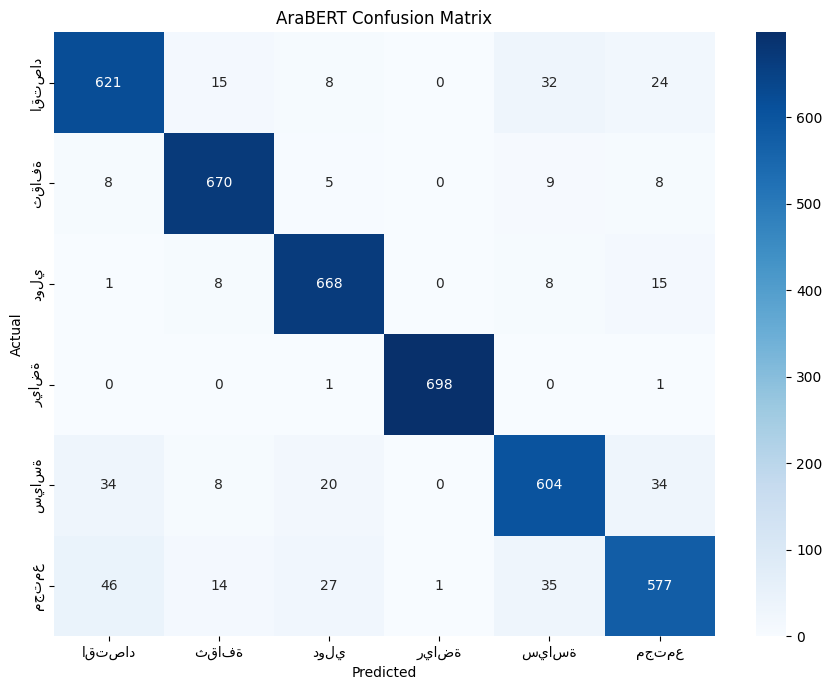

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AraBERT Confusion Matrix")
plt.tight_layout()
plt.show()